# Ski Country USA and the Traffic It Creates

## Data preperations:

Need to download the data and organize it in a useable way. This may look different for the different ways we want to analyze the data.

We have downloaded the data from CDOT's "Traffic Data Explorer" site - https://dtdapps.coloradodot.info/otis/trafficdata#ui/1/0/2/station/000120/criteria/070A/205/250/false/true/

Since we are interested in the stretch of I-70 between Denver, we searched along that route to find count stations. There are two stations in this zone that we will be using, one just west of Idahp Springs, and another in the Eisenhower Tunnel at the top of Loveland Pass.

The data goes back to 1996, however for the Idaho Springs station, the data for 1996 and 1997 is not complete, so we will be dropping these years from the analysis and only focusing on 1998-2024.

Lets take a look at what downloading one year of data looks like.

In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ET_1998 = pd.read_csv('traffic_data/ET/ET_1998.csv')
print(ET_1998.head())
IS_1998 = pd.read_csv('traffic_data/IS/IS_1998.csv')
print(IS_1998.head())

   COUNTSTATIONID  COUNTDATE COUNTDIR  HOUR0  HOUR1  HOUR2  HOUR3  HOUR4  \
0             106   19980101        P     52     67     81     54     67   
1             106   19980101        S     93     81     62     59     73   
2             106   19980102        P     69     51     69     72     80   
3             106   19980102        S     95     67     47     41     78   
4             106   19980103        P    114     88     70     79    105   

   HOUR5  HOUR6  ...  HOUR15  HOUR16  HOUR17  HOUR18  HOUR19  HOUR20  HOUR21  \
0    113    168  ...    1522    1870    1684    1097     828     624     422   
1     67    159  ...    1278     853     597     485     382     296     273   
2    206    401  ...    1783    2050    1929    1160     727     484     415   
3    129    316  ...     971    1028     873     748     604     474     347   
4    216    429  ...    1858    2010    1631     993     727     524     367   

   HOUR22  HOUR23  FormattedDate  
0     256     144     01/01

As we can see from the snapshot above, the data is organized by Station ID, Count Date and direction the traffic is going, with subsequent columns for each hour in the day (0-23). One thing that stands out right away is the lack of data on what day of the week each date is. Once we join all of the data, we will need to use pandas to add that column.

Below, we will combine all of our data into two main dataframes, on for the Eisenhower tunnel at the end of our route, and one for Idaho Springs at the beginning of our route. We will use these as our main dataframes to manipulate and analyze data.

In [3]:
import glob
import os
# Defining path to the data files and combining them into one file to iterate over
ET_path = r'traffic_data/ET'
IS_path = r'traffic_data/IS'
all_ET_files = glob.glob(os.path.join(ET_path, "*.csv"))
all_IS_files = glob.glob(os.path.join(IS_path, "*.csv"))

# lists to hold data
ET_li = []
IS_li = []

# opening each csv and as a pandas dataframe and adding it to the list
for filename in all_ET_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    ET_li.append(df)

for filename in all_IS_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    IS_li.append(df)

# combining all dataframes in the list into one dataframe
ET_combo = pd.concat(ET_li, axis=0, ignore_index=True)
IS_combo = pd.concat(IS_li, axis=0, ignore_index=True)

# sanity check!
print("ET Head: ", ET_combo.head())
print("ET Tail", ET_combo.tail())
print("IS Head: ", IS_combo.head())
print("IS Tail", IS_combo.tail())

ET Head:     COUNTSTATIONID  COUNTDATE COUNTDIR  HOUR0  HOUR1  HOUR2  HOUR3  HOUR4  \
0             106   20010101        P     78     84     92     94     91   
1             106   20010101        S     67     79     67     59     35   
2             106   20010102        P    146     96     65     88    121   
3             106   20010102        S     84     70     81     58    103   
4             106   20010103        P    113     81     56     53     87   

   HOUR5  HOUR6  ...  HOUR15  HOUR16  HOUR17  HOUR18  HOUR19  HOUR20  HOUR21  \
0    147    243  ...    2483    1690    1779    1877    1386     806     527   
1     65    226  ...     965     748     644     514     397     315     278   
2    318    507  ...    1728    1970    1771     959     632     449     323   
3    229    413  ...     842     729     628     540     490     358     271   
4    160    254  ...    1361    1642    1326     757     494     339     292   

   HOUR22  HOUR23  FormattedDate  
0     323     219

In order to properly analyze our data later, we need to add in days of the week to our data, we can do this using pandas "Date time index" to add a column with this data as shown below. This pandas function adds days of the week as an integer, 0-6, with 0 being Monday, and 6 being Sunday. Unfortunately, this requires a properly formatted date, so we will need to make that column first.

In [4]:
# Format the date properly for pandas
ET_combo['COUNTDATE'] = pd.to_datetime(ET_combo['COUNTDATE'], format='%Y%m%d')
IS_combo['COUNTDATE'] = pd.to_datetime(IS_combo['COUNTDATE'], format='%Y%m%d')


# Add column for day of the week
ET_combo['Day of the Week'] = ET_combo['COUNTDATE'].dt.dayofweek
print(ET_combo.head())
IS_combo['Day of the Week'] = IS_combo['COUNTDATE'].dt.dayofweek
print(IS_combo.head())

   COUNTSTATIONID  COUNTDATE COUNTDIR  HOUR0  HOUR1  HOUR2  HOUR3  HOUR4  \
0             106 2001-01-01        P     78     84     92     94     91   
1             106 2001-01-01        S     67     79     67     59     35   
2             106 2001-01-02        P    146     96     65     88    121   
3             106 2001-01-02        S     84     70     81     58    103   
4             106 2001-01-03        P    113     81     56     53     87   

   HOUR5  HOUR6  ...  HOUR16  HOUR17  HOUR18  HOUR19  HOUR20  HOUR21  HOUR22  \
0    147    243  ...    1690    1779    1877    1386     806     527     323   
1     65    226  ...     748     644     514     397     315     278     202   
2    318    507  ...    1970    1771     959     632     449     323     206   
3    229    413  ...     729     628     540     490     358     271     333   
4    160    254  ...    1642    1326     757     494     339     292     170   

   HOUR23  FormattedDate  Day of the Week  
0     219     01/0

# Analyzing traffic data on a yearly level

All of our data is seperated by day, hour and direction. This will be helpful later, but is not what we need to analyze yearly trends. To find the totals on the years, we will add a new column to our main table called 'Daily Totals' which we can then use to get yearly and monthly totals later.

In [5]:
ET_combo['Daily Totals'] = ET_combo[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']].sum(axis=1)
IS_combo['Daily Totals'] = IS_combo[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']].sum(axis=1)
#print(ET_combo.head())
#print(IS_combo.head())
#ET_1998 = ET_combo[ET_combo['COUNTDATE'].dt.year == 1998]
#print(ET_1998)
#IS_1998 = IS_combo[IS_combo['COUNTDATE'].dt.year == 1998]
#print(IS_1998)

In [6]:
dictionary_ET = {}
dictionary_IS = {}
for i in range(1998, 2022):
    data = ET_combo[ET_combo['COUNTDATE'].dt.year == i]
    dictionary_ET[i] = data['Daily Totals'].sum()

for i in range(1998, 2022):
    data = IS_combo[IS_combo['COUNTDATE'].dt.year == i]
    dictionary_IS[i] = data['Daily Totals'].sum()
    
#print(dictionary_ET, dictionary_IS)

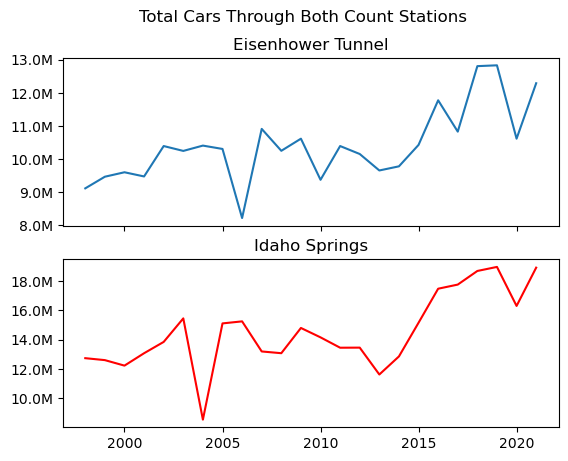

In [7]:
import matplotlib.ticker as ticker

years_ET = list(dictionary_ET.keys())
values_ET = list(dictionary_ET.values())
years_IS = list(dictionary_IS.keys())
values_IS = list(dictionary_IS.values())

def millions_format(x, pos):
    return f'{x / 1e6:1.1f}M'

formatter = ticker.FuncFormatter(millions_format)

fig, axs = plt.subplots(2)
fig.suptitle('Total Cars Through Both Count Stations')
axs[0].plot(years_ET, values_ET)
axs[0].set_title('Eisenhower Tunnel')
axs[0].label_outer()
axs[0].yaxis.set_major_formatter(formatter)
axs[1].plot(years_IS, values_IS, color='red')
axs[1].set_title('Idaho Springs')
axs[1].yaxis.set_major_formatter(formatter)
#plt.bar(years_ET, values_ET, color='blue')
#plt.xlabel('Year')
#plt.ylabel('Number of Cars')
#plt.title('Number of Cars Over the Years - Eisenhower Tunnel')

As we can see from the charts above, the total amount of cars going both ways on I-70 in both Idaho Springs and the Eisenhower Tunnel have tended in a positive direction. This shows the growth of traffic on the highway, and why having more information on when peak times may be hitting to avoid traffic issues could be of value to drivers and folks that live in the area.

# Diving into monthly trends

Now we want to look at each month to see how they have contributed to this gradual build in traffic over time.

To do that, we are going to look at the average Daily Totals that we calculated early for each month and how they have changed over time. We will organize our data in a similar way to how we looked at the yearly trends with a dictionary of values.

In [8]:
# Here we are using defaultdict to created a nested dictionary with the first entry being the month (1-12) and the second being the year (1998-2021).
# The nested dictionary allows us to easily pick a specific month and view the average count for whatever year we choose.

from collections import defaultdict

monthly_ET= defaultdict(dict)
monthly_IS = defaultdict(dict)

for i in range(1998, 2022):
    for j in range(1,13):
        data = ET_combo[(ET_combo['COUNTDATE'].dt.year == i) & (ET_combo['COUNTDATE'].dt.month == j)]
        monthly_ET[j][i] = data['Daily Totals'].mean()

for i in range(1998, 2022):
    for j in range(1,13):
        data = IS_combo[(IS_combo['COUNTDATE'].dt.year == i) & (IS_combo['COUNTDATE'].dt.month == j)]
        monthly_IS[j][i] = data['Daily Totals'].mean()
    
#print(monthly_ET[9])

Now that the data is organized how we want it, lets make a visual to see trends.

Text(0.5, 1.0, 'December')

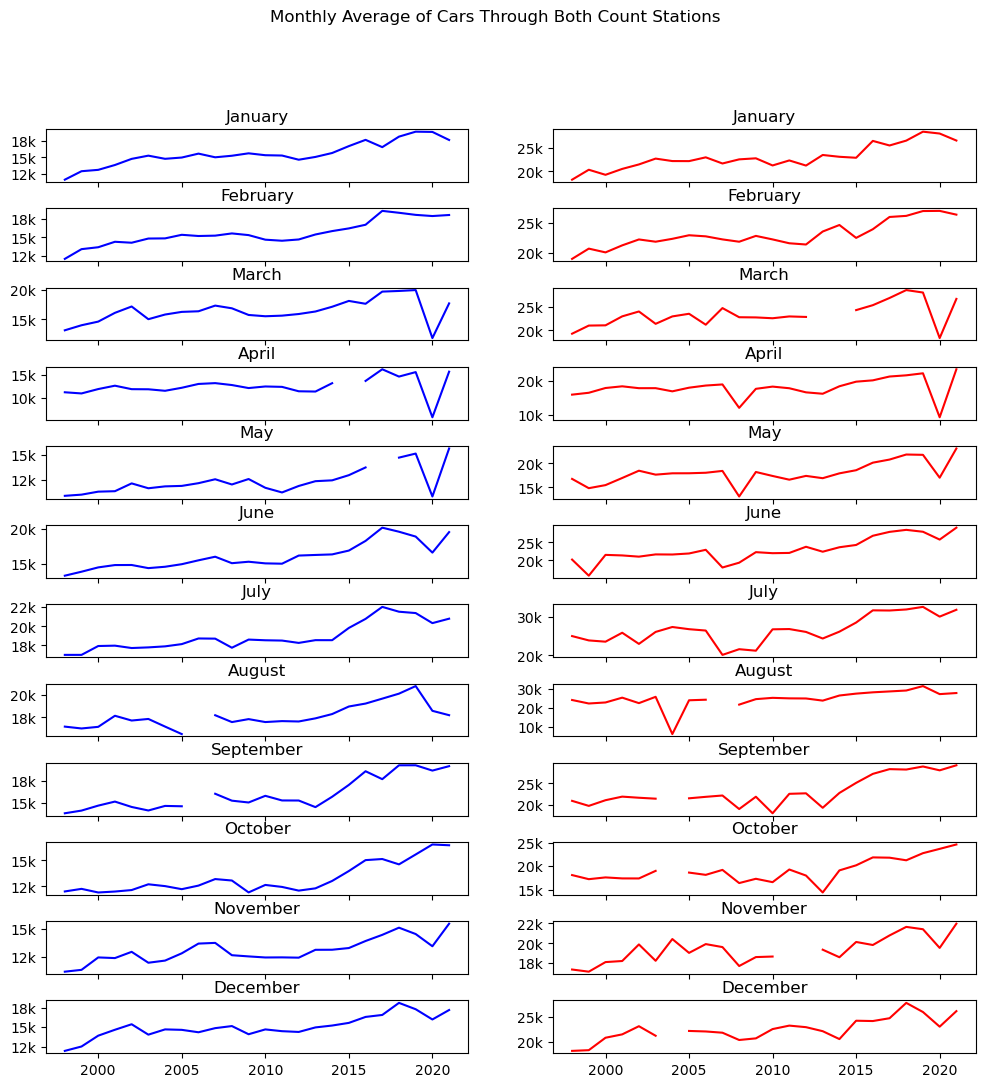

In [9]:
# I would like to apologize in advance for all of the hard-coding below. I know there is a way to optimize this but I spent a bit too much time trying
# to do that and eventually settled on this.

years_jan_ET = list(monthly_ET[1].keys())
values_jan_ET = list(monthly_ET[1].values())
years_feb_ET = list(monthly_ET[2].keys())
values_feb_ET = list(monthly_ET[2].values())
years_mar_ET = list(monthly_ET[3].keys())
values_mar_ET = list(monthly_ET[3].values())
years_apr_ET = list(monthly_ET[4].keys())
values_apr_ET = list(monthly_ET[4].values())
years_may_ET = list(monthly_ET[5].keys())
values_may_ET = list(monthly_ET[5].values())
years_jun_ET = list(monthly_ET[6].keys())
values_jun_ET = list(monthly_ET[6].values())
years_jul_ET = list(monthly_ET[7].keys())
values_jul_ET = list(monthly_ET[7].values())
years_aug_ET = list(monthly_ET[8].keys())
values_aug_ET = list(monthly_ET[8].values())
years_sep_ET = list(monthly_ET[9].keys())
values_sep_ET = list(monthly_ET[9].values())
years_oct_ET = list(monthly_ET[10].keys())
values_oct_ET = list(monthly_ET[10].values())
years_nov_ET = list(monthly_ET[11].keys())
values_nov_ET = list(monthly_ET[11].values())
years_dec_ET = list(monthly_ET[12].keys())
values_dec_ET = list(monthly_ET[12].values())

years_jan_IS = list(monthly_IS[1].keys())
values_jan_IS = list(monthly_IS[1].values())
years_feb_IS = list(monthly_IS[2].keys())
values_feb_IS = list(monthly_IS[2].values())
years_mar_IS = list(monthly_IS[3].keys())
values_mar_IS = list(monthly_IS[3].values())
years_apr_IS = list(monthly_IS[4].keys())
values_apr_IS = list(monthly_IS[4].values())
years_may_IS = list(monthly_IS[5].keys())
values_may_IS = list(monthly_IS[5].values())
years_jun_IS = list(monthly_IS[6].keys())
values_jun_IS = list(monthly_IS[6].values())
years_jul_IS = list(monthly_IS[7].keys())
values_jul_IS = list(monthly_IS[7].values())
years_aug_IS = list(monthly_IS[8].keys())
values_aug_IS = list(monthly_IS[8].values())
years_sep_IS = list(monthly_IS[9].keys())
values_sep_IS = list(monthly_IS[9].values())
years_oct_IS = list(monthly_IS[10].keys())
values_oct_IS = list(monthly_IS[10].values())
years_nov_IS = list(monthly_IS[11].keys())
values_nov_IS = list(monthly_IS[11].values())
years_dec_IS = list(monthly_IS[12].keys())
values_dec_IS = list(monthly_IS[12].values())   

def thousands_format(x, pos):
   return f'{x / 1e3:1.0f}k'

format_thousands = ticker.FuncFormatter(thousands_format)

fig, axs = plt.subplots(12, 2, figsize=(12,12))
fig.suptitle('Monthly Average of Cars Through Both Count Stations')
plt.subplots_adjust(hspace=0.5)
axs[0, 0].set_title('January')
axs[0, 0].plot(years_jan_ET, values_jan_ET, color='blue')
axs[0, 0].yaxis.set_major_formatter(format_thousands)
axs[0, 0].label_outer()
axs[0, 1].plot(years_jan_IS, values_jan_IS, color='red')
axs[0, 1].yaxis.set_major_formatter(format_thousands)
axs[0, 1].set_title('January')
axs[0, 1].set_xticklabels([])
axs[1, 0].plot(years_feb_ET, values_feb_ET, color='blue')
axs[1, 0].yaxis.set_major_formatter(format_thousands)
axs[1, 0].set_title('February')
axs[1, 0].label_outer()
axs[1, 1].plot(years_feb_IS, values_feb_IS, color='red')
axs[1, 1].yaxis.set_major_formatter(format_thousands)
axs[1, 1].set_title('February')
axs[1, 1].set_xticklabels([])
axs[2, 0].plot(years_mar_ET, values_mar_ET, color='blue')
axs[2, 0].yaxis.set_major_formatter(format_thousands)
axs[2, 0].set_title('March')
axs[2, 0].label_outer()
axs[2, 1].plot(years_mar_IS, values_mar_IS, color='red')
axs[2, 1].yaxis.set_major_formatter(format_thousands)
axs[2, 1].set_title('March')
axs[2, 1].set_xticklabels([])
axs[3, 0].plot(years_apr_ET, values_apr_ET, color='blue')
axs[3, 0].yaxis.set_major_formatter(format_thousands)
axs[3, 0].set_title('April')
axs[3, 0].label_outer()
axs[3, 1].plot(years_apr_IS, values_apr_IS, color='red')
axs[3, 1].yaxis.set_major_formatter(format_thousands)
axs[3, 1].set_title('April')
axs[3, 1].set_xticklabels([])
axs[4, 0].plot(years_may_ET, values_may_ET, color='blue')
axs[4, 0].yaxis.set_major_formatter(format_thousands)
axs[4, 0].set_title('May')
axs[4, 0].label_outer()
axs[4, 1].plot(years_may_IS, values_may_IS, color='red')
axs[4, 1].yaxis.set_major_formatter(format_thousands)
axs[4, 1].set_title('May')
axs[4, 1].set_xticklabels([])
axs[5, 0].plot(years_jun_ET, values_jun_ET, color='blue')
axs[5, 0].yaxis.set_major_formatter(format_thousands)
axs[5, 0].set_title('June')
axs[5, 0].label_outer()
axs[5, 1].plot(years_jun_IS, values_jun_IS, color='red')
axs[5, 1].yaxis.set_major_formatter(format_thousands)
axs[5, 1].set_title('June')
axs[5, 1].set_xticklabels([])
axs[6, 0].plot(years_jul_ET, values_jul_ET, color='blue')
axs[6, 0].yaxis.set_major_formatter(format_thousands)
axs[6, 0].set_title('July')
axs[6, 0].label_outer()
axs[6, 1].plot(years_jul_IS, values_jul_IS, color='red')
axs[6, 1].yaxis.set_major_formatter(format_thousands)
axs[6, 1].set_title('July')
axs[6, 1].set_xticklabels([])
axs[7, 1].plot(years_aug_IS, values_aug_IS, color='red')
axs[7, 1].yaxis.set_major_formatter(format_thousands)
axs[7, 1].set_title('August')
axs[7, 1].set_xticklabels([])
axs[7, 0].plot(years_aug_ET, values_aug_ET, color='blue')
axs[7, 0].yaxis.set_major_formatter(format_thousands)
axs[7, 0].set_title('August')
axs[7, 0].label_outer()
axs[8, 1].plot(years_sep_IS, values_sep_IS, color='red')
axs[8, 1].yaxis.set_major_formatter(format_thousands)
axs[8, 1].set_title('September')
axs[8, 1].set_xticklabels([])
axs[8, 0].plot(years_sep_ET, values_sep_ET, color='blue')
axs[8, 0].yaxis.set_major_formatter(format_thousands)
axs[8, 0].set_title('September')
axs[8, 0].label_outer()
axs[9, 1].plot(years_oct_IS, values_oct_IS, color='red')
axs[9, 1].yaxis.set_major_formatter(format_thousands)
axs[9, 1].set_title('October')
axs[9, 1].set_xticklabels([])
axs[9, 0].plot(years_oct_ET, values_oct_ET, color='blue')
axs[9, 0].yaxis.set_major_formatter(format_thousands)
axs[9, 0].set_title('October')
axs[9, 0].label_outer()
axs[10, 0].plot(years_nov_ET, values_nov_ET, color='blue')
axs[10, 0].yaxis.set_major_formatter(format_thousands)
axs[10, 0].set_title('November')
axs[10, 0].label_outer()
axs[10, 1].plot(years_nov_IS, values_nov_IS, color='red')
axs[10, 1].yaxis.set_major_formatter(format_thousands)
axs[10, 1].set_title('November')
axs[10, 1].set_xticklabels([])
axs[11, 0].plot(years_dec_ET, values_dec_ET, color='blue')
axs[11, 0].yaxis.set_major_formatter(format_thousands)
axs[11, 0].set_title('December')
axs[11, 0].label_outer()
axs[11, 1].plot(years_dec_IS, values_dec_IS, color='red')
axs[11, 1].yaxis.set_major_formatter(format_thousands)
axs[11, 1].set_title('December')

The results above are interesting, and show definite trends upwards, like we saw with the yearly breakdowns. We can clearly see a drop in traffic during the shutdowns in March, April, and May of 2020. We can also see that July is amongst the most popular months for travel at both stations.

We can also see that the counter for the Eisenhower Tunnel was down during September and October of 2006, and the counter at Idaho Springs was down during September, October, and December of 2004. These gaps help explain the dip in total car count we can see in the yearly totals.

# Looking at days of the week.

In [10]:
daily_ET = defaultdict(dict)
daily_IS = defaultdict(dict)

for i in range(1998, 2022):
    for j in range(0,7):
        data = ET_combo[(ET_combo['COUNTDATE'].dt.year == i) & (ET_combo['Day of the Week'] == j)]
        daily_ET[j][i] = data['Daily Totals'].mean()

for i in range(1998, 2022):
    for j in range(0,7):
        data = IS_combo[(IS_combo['COUNTDATE'].dt.year == i) & (IS_combo['Day of the Week'] == j)]
        daily_IS[j][i] = data['Daily Totals'].mean()
    
#print(daily_ET[0])

[Text(1995.0, 0, ''),
 Text(2000.0, 0, ''),
 Text(2005.0, 0, ''),
 Text(2010.0, 0, ''),
 Text(2015.0, 0, ''),
 Text(2020.0, 0, ''),
 Text(2025.0, 0, '')]

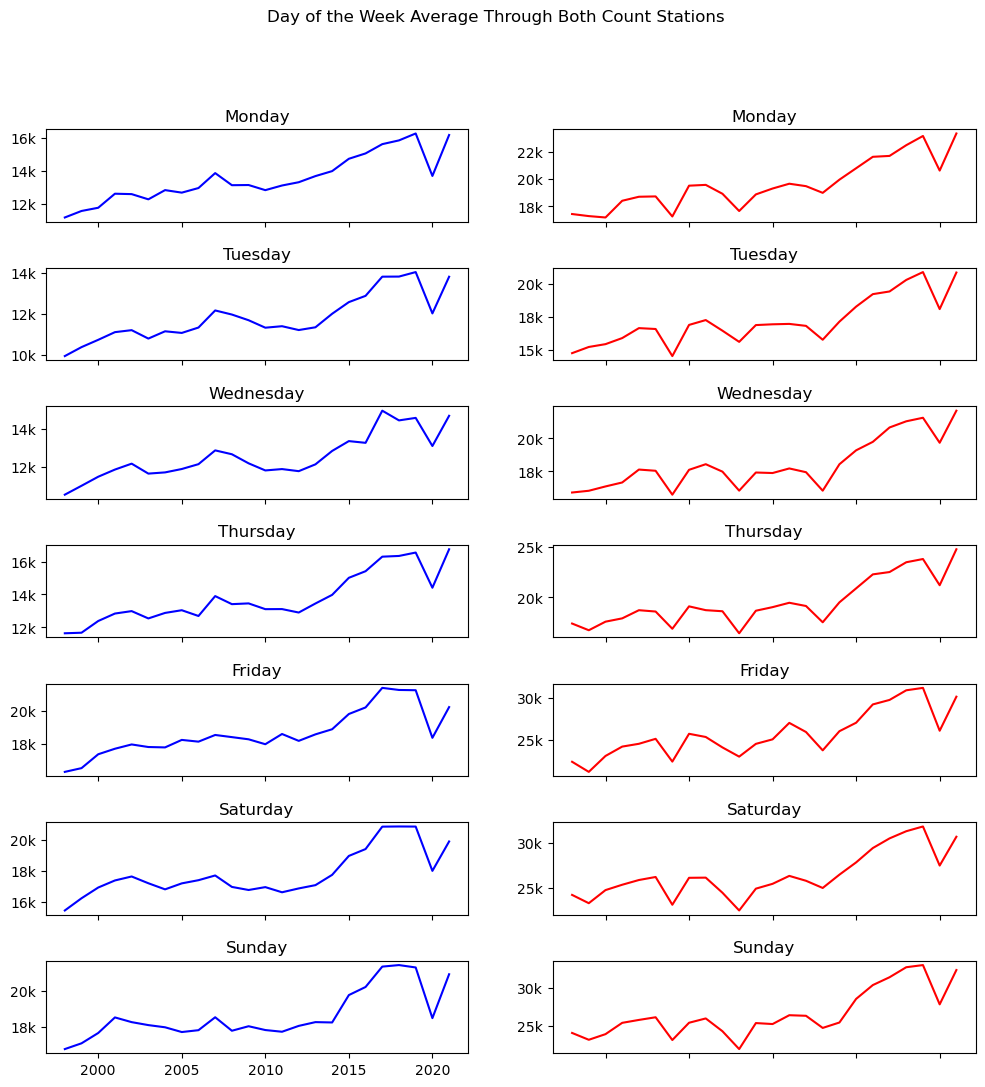

In [11]:
years_mon_ET = list(daily_ET[0].keys())
values_mon_ET = list(daily_ET[0].values())
years_tue_ET = list(daily_ET[1].keys())
values_tue_ET = list(daily_ET[1].values())
years_wed_ET = list(daily_ET[2].keys())
values_wed_ET = list(daily_ET[2].values())
years_thu_ET = list(daily_ET[3].keys())
values_thu_ET = list(daily_ET[3].values())
years_fri_ET = list(daily_ET[4].keys())
values_fri_ET = list(daily_ET[4].values())
years_sat_ET = list(daily_ET[5].keys())
values_sat_ET = list(daily_ET[5].values())
years_sun_ET = list(daily_ET[6].keys())
values_sun_ET = list(daily_ET[6].values())

years_mon_IS = list(daily_IS[0].keys())
values_mon_IS = list(daily_IS[0].values())
years_tue_IS = list(daily_IS[1].keys())
values_tue_IS = list(daily_IS[1].values())
years_wed_IS = list(daily_IS[2].keys())
values_wed_IS = list(daily_IS[2].values())
years_thu_IS = list(daily_IS[3].keys())
values_thu_IS = list(daily_IS[3].values())
years_fri_IS = list(daily_IS[4].keys())
values_fri_IS = list(daily_IS[4].values())
years_sat_IS = list(daily_IS[5].keys())
values_sat_IS = list(daily_IS[5].values())
years_sun_IS = list(daily_IS[6].keys())
values_sun_IS = list(daily_IS[6].values())

def thousands_format(x, pos):
   return f'{x / 1e3:1.0f}k'

format_thousands = ticker.FuncFormatter(thousands_format)

fig, axs = plt.subplots(7, 2, figsize=(12,12))
fig.suptitle('Day of the Week Average Through Both Count Stations')
plt.subplots_adjust(hspace=0.5)
axs[0, 0].set_title('Monday')
axs[0, 0].plot(years_mon_ET, values_mon_ET, color='blue')
axs[0, 0].yaxis.set_major_formatter(format_thousands)
axs[0, 0].label_outer()
axs[0, 1].plot(years_mon_IS, values_mon_IS, color='red')
axs[0, 1].yaxis.set_major_formatter(format_thousands)
axs[0, 1].set_title('Monday')
axs[0, 1].set_xticklabels([])
axs[1, 0].plot(years_tue_ET, values_tue_ET, color='blue')
axs[1, 0].yaxis.set_major_formatter(format_thousands)
axs[1, 0].set_title('Tuesday')
axs[1, 0].label_outer()
axs[1, 1].plot(years_tue_IS, values_tue_IS, color='red')
axs[1, 1].yaxis.set_major_formatter(format_thousands)
axs[1, 1].set_title('Tuesday')
axs[1, 1].set_xticklabels([])
axs[2, 0].plot(years_wed_ET, values_wed_ET, color='blue')
axs[2, 0].yaxis.set_major_formatter(format_thousands)
axs[2, 0].set_title('Wednesday')
axs[2, 0].label_outer()
axs[2, 1].plot(years_wed_IS, values_wed_IS, color='red')
axs[2, 1].yaxis.set_major_formatter(format_thousands)
axs[2, 1].set_title('Wednesday')
axs[2, 1].set_xticklabels([])
axs[3, 0].plot(years_thu_ET, values_thu_ET, color='blue')
axs[3, 0].yaxis.set_major_formatter(format_thousands)
axs[3, 0].set_title('Thursday')
axs[3, 0].label_outer()
axs[3, 1].plot(years_thu_IS, values_thu_IS, color='red')
axs[3, 1].yaxis.set_major_formatter(format_thousands)
axs[3, 1].set_title('Thursday')
axs[3, 1].set_xticklabels([])
axs[4, 0].plot(years_fri_ET, values_fri_ET, color='blue')
axs[4, 0].yaxis.set_major_formatter(format_thousands)
axs[4, 0].set_title('Friday')
axs[4, 0].label_outer()
axs[4, 1].plot(years_fri_IS, values_fri_IS, color='red')
axs[4, 1].yaxis.set_major_formatter(format_thousands)
axs[4, 1].set_title('Friday')
axs[4, 1].set_xticklabels([])
axs[5, 0].plot(years_sat_ET, values_sat_ET, color='blue')
axs[5, 0].yaxis.set_major_formatter(format_thousands)
axs[5, 0].set_title('Saturday')
axs[5, 0].label_outer()
axs[5, 1].plot(years_sat_IS, values_sat_IS, color='red')
axs[5, 1].yaxis.set_major_formatter(format_thousands)
axs[5, 1].set_title('Saturday')
axs[5, 1].set_xticklabels([])
axs[6, 0].plot(years_sun_ET, values_sun_ET, color='blue')
axs[6, 0].yaxis.set_major_formatter(format_thousands)
axs[6, 0].set_title('Sunday')
axs[6, 0].label_outer()
axs[6, 1].plot(years_sun_IS, values_sun_IS, color='red')
axs[6, 1].yaxis.set_major_formatter(format_thousands)
axs[6, 1].set_title('Sunday')
axs[6, 1].set_xticklabels([])

# Hourly Averages

Text(0.5, 1.0, 'Idaho Springs')

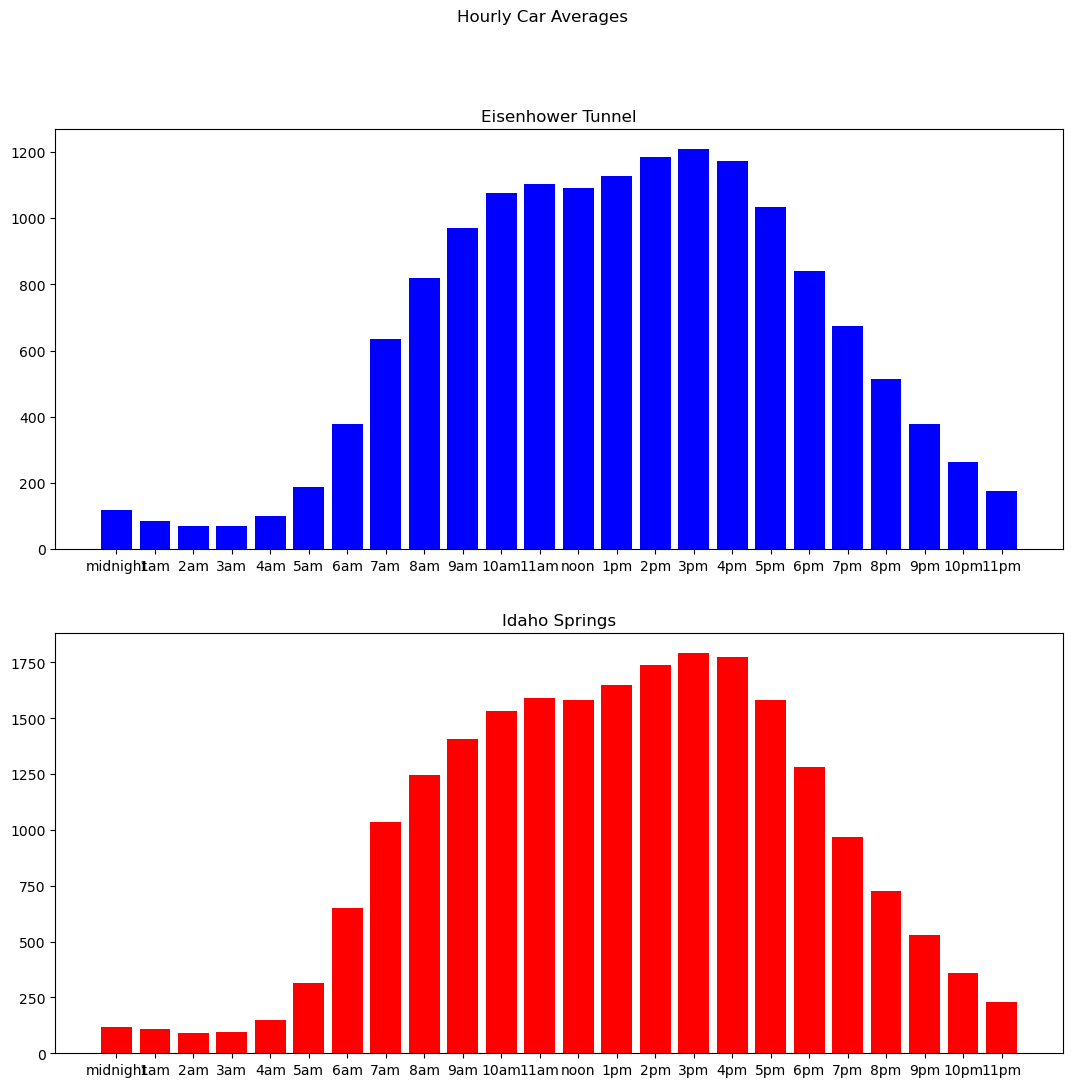

In [12]:
ET_hourly_dict = {}
IS_hourly_dict = {}

ET_hourly_dict['midnight'] = ET_combo['HOUR0'].mean()
ET_hourly_dict['1am'] = ET_combo['HOUR1'].mean()
ET_hourly_dict['2am'] = ET_combo['HOUR2'].mean()
ET_hourly_dict['3am'] = ET_combo['HOUR3'].mean()
ET_hourly_dict['4am'] = ET_combo['HOUR4'].mean()
ET_hourly_dict['5am'] = ET_combo['HOUR5'].mean()
ET_hourly_dict['6am'] = ET_combo['HOUR6'].mean()
ET_hourly_dict['7am'] = ET_combo['HOUR7'].mean()
ET_hourly_dict['8am'] = ET_combo['HOUR8'].mean()
ET_hourly_dict['9am'] = ET_combo['HOUR9'].mean()
ET_hourly_dict['10am'] = ET_combo['HOUR10'].mean()
ET_hourly_dict['11am'] = ET_combo['HOUR11'].mean()
ET_hourly_dict['noon'] = ET_combo['HOUR12'].mean()
ET_hourly_dict['1pm'] = ET_combo['HOUR13'].mean()
ET_hourly_dict['2pm'] = ET_combo['HOUR14'].mean()
ET_hourly_dict['3pm'] = ET_combo['HOUR15'].mean()
ET_hourly_dict['4pm'] = ET_combo['HOUR16'].mean()
ET_hourly_dict['5pm'] = ET_combo['HOUR17'].mean()
ET_hourly_dict['6pm'] = ET_combo['HOUR18'].mean()
ET_hourly_dict['7pm'] = ET_combo['HOUR19'].mean()
ET_hourly_dict['8pm'] = ET_combo['HOUR20'].mean()
ET_hourly_dict['9pm'] = ET_combo['HOUR21'].mean()
ET_hourly_dict['10pm'] = ET_combo['HOUR22'].mean()
ET_hourly_dict['11pm'] = ET_combo['HOUR23'].mean()

IS_hourly_dict['midnight'] = ET_combo['HOUR0'].mean()
IS_hourly_dict['1am'] = IS_combo['HOUR1'].mean()
IS_hourly_dict['2am'] = IS_combo['HOUR2'].mean()
IS_hourly_dict['3am'] = IS_combo['HOUR3'].mean()
IS_hourly_dict['4am'] = IS_combo['HOUR4'].mean()
IS_hourly_dict['5am'] = IS_combo['HOUR5'].mean()
IS_hourly_dict['6am'] = IS_combo['HOUR6'].mean()
IS_hourly_dict['7am'] = IS_combo['HOUR7'].mean()
IS_hourly_dict['8am'] = IS_combo['HOUR8'].mean()
IS_hourly_dict['9am'] = IS_combo['HOUR9'].mean()
IS_hourly_dict['10am'] = IS_combo['HOUR10'].mean()
IS_hourly_dict['11am'] = IS_combo['HOUR11'].mean()
IS_hourly_dict['noon'] = IS_combo['HOUR12'].mean()
IS_hourly_dict['1pm'] = IS_combo['HOUR13'].mean()
IS_hourly_dict['2pm'] = IS_combo['HOUR14'].mean()
IS_hourly_dict['3pm'] = IS_combo['HOUR15'].mean()
IS_hourly_dict['4pm'] = IS_combo['HOUR16'].mean()
IS_hourly_dict['5pm'] = IS_combo['HOUR17'].mean()
IS_hourly_dict['6pm'] = IS_combo['HOUR18'].mean()
IS_hourly_dict['7pm'] = IS_combo['HOUR19'].mean()
IS_hourly_dict['8pm'] = IS_combo['HOUR20'].mean()
IS_hourly_dict['9pm'] = IS_combo['HOUR21'].mean()
IS_hourly_dict['10pm'] = IS_combo['HOUR22'].mean()
IS_hourly_dict['11pm'] = IS_combo['HOUR23'].mean()

ET_hours = list(ET_hourly_dict.keys())
ET_values = list(ET_hourly_dict.values())

IS_hours = list(IS_hourly_dict.keys())
IS_values = list(IS_hourly_dict.values())


fig, axs = plt.subplots(2, figsize=(13,12))
fig.suptitle('Hourly Car Averages')
axs[0].bar(ET_hours, ET_values, color='blue')
axs[0].set_title('Eisenhower Tunnel')
axs[1].bar(IS_hours, IS_values, color='red')
axs[1].set_title('Idaho Springs')

# Making a decision tree

In order to make this data easy to use and interpret, we will be making a decision tree based on how much traffic will be on your route. We will use the which count point they are driving past, day of the week, time of day, month of the year, and direction of traffic to help determine if you will have low, medium, or high volume of cars on your drive.

First, we are going to determine what ranges will capture low, medium and high traffic. To do this, we will put all of the data values in 3 bins to determine what belongs where.

In [13]:
ET_stacked = ET_combo[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']].stack()
ET_tertiles = ET_stacked.quantile([1/3,2/3])
ET_minimum = ET_stacked.min()
ET_maximum = ET_stacked.max()
print("Tertiles: ", ET_tertiles)
print("Min: ", ET_minimum)
print("Max: ", ET_maximum)

Tertiles:  0.333333    260.0
0.666667    810.0
dtype: float64
Min:  0
Max:  5625


In [14]:
IS_stacked = IS_combo[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']].stack()
IS_tertiles = IS_stacked.quantile([1/3,2/3])
IS_minimum = IS_stacked.min()
IS_maximum = IS_stacked.max()
print("Tertiles: ", IS_tertiles)
print("Min: ", IS_minimum)
print("Max: ", IS_maximum)

Tertiles:  0.333333     380.0
0.666667    1170.0
dtype: float64
Min:  0
Max:  9317


No we have our cutoffs for our 3 bins that will help determine how many cars are on the highway when you are trying to commute. Anything up to 260 cars a minute is considered "low", 260 < x < 810 is medium, and anything above 810 is considered high.

Now we will create a different dataframe that instead of having the counts of cars, will simply say whether the traffic was "low", "medium" or "high" at that time.

In [15]:
ET_param = ET_combo
IS_param = IS_combo

# defining our parameters for what is low, medium, and high
ET_conditions = [
    (ET_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] < 260),
    (ET_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] < 810),
    (ET_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] >= 810)
]

# actual strings to be inserted
ET_choices = ['low', 'medium', 'high']

# inserting into the dataframe based on conditions
ET_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] = np.select(ET_conditions, ET_choices, default='other')
print(ET_param)

# defining our parameters for what is low, medium, and high
IS_conditions = [
    (IS_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] < 380),
    (IS_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] < 1170),
    (IS_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] >= 1170)
]

# actual strings to be inserted
IS_choices = ['low', 'medium', 'high']

# inserting into the dataframe based on conditions
IS_param[['HOUR0','HOUR1','HOUR2','HOUR3','HOUR4','HOUR5','HOUR6','HOUR7','HOUR8','HOUR9','HOUR10','HOUR11','HOUR12','HOUR13','HOUR14','HOUR15','HOUR16','HOUR17','HOUR18','HOUR19','HOUR20','HOUR21','HOUR22','HOUR23']] = np.select(IS_conditions, IS_choices, default='other')
print(IS_param)

       COUNTSTATIONID  COUNTDATE COUNTDIR HOUR0 HOUR1 HOUR2 HOUR3 HOUR4  \
0                 106 2001-01-01        P   low   low   low   low   low   
1                 106 2001-01-01        S   low   low   low   low   low   
2                 106 2001-01-02        P   low   low   low   low   low   
3                 106 2001-01-02        S   low   low   low   low   low   
4                 106 2001-01-03        P   low   low   low   low   low   
...               ...        ...      ...   ...   ...   ...   ...   ...   
19808             106 2021-12-29        S   low   low   low   low   low   
19809             106 2021-12-30        P   low   low   low   low   low   
19810             106 2021-12-30        S   low   low   low   low   low   
19811             106 2021-12-31        P   low   low   low   low   low   
19812             106 2021-12-31        S   low   low   low   low   low   

        HOUR5   HOUR6  ...  HOUR17  HOUR18  HOUR19  HOUR20  HOUR21  HOUR22  \
0         low     low

One more thing we are going to do to make our calculations easier, is melt the dataframe so that each hour in the day gets its own row. This is going to drastically increase our amount of rows but will make the calculations for information gain we need to do next much easier,

In [16]:
combo_param = pd.concat([ET_param, IS_param], ignore_index=True)
print(combo_param)

       COUNTSTATIONID  COUNTDATE COUNTDIR HOUR0 HOUR1 HOUR2 HOUR3 HOUR4  \
0                 106 2001-01-01        P   low   low   low   low   low   
1                 106 2001-01-01        S   low   low   low   low   low   
2                 106 2001-01-02        P   low   low   low   low   low   
3                 106 2001-01-02        S   low   low   low   low   low   
4                 106 2001-01-03        P   low   low   low   low   low   
...               ...        ...      ...   ...   ...   ...   ...   ...   
37789             120 1998-12-29        S   low   low   low   low   low   
37790             120 1998-12-30        P   low   low   low   low   low   
37791             120 1998-12-30        S   low   low   low   low   low   
37792             120 1998-12-31        P   low   low   low   low   low   
37793             120 1998-12-31        S   low   low   low   low   low   

        HOUR5   HOUR6  ...  HOUR17  HOUR18  HOUR19  HOUR20  HOUR21  HOUR22  \
0         low     low

In [17]:
melted_df = combo_param.melt(
    id_vars=['COUNTSTATIONID', 'COUNTDATE', 'COUNTDIR','FormattedDate', 'Day of the Week', 'Daily Totals'],
    var_name='Hour',
    value_name='Traffic Volume'
)
melted_df = melted_df.drop(columns=['FormattedDate', 'Daily Totals'])

In [18]:
print(melted_df)

        COUNTSTATIONID  COUNTDATE COUNTDIR  Day of the Week    Hour  \
0                  106 2001-01-01        P                0   HOUR0   
1                  106 2001-01-01        S                0   HOUR0   
2                  106 2001-01-02        P                1   HOUR0   
3                  106 2001-01-02        S                1   HOUR0   
4                  106 2001-01-03        P                2   HOUR0   
...                ...        ...      ...              ...     ...   
907051             120 1998-12-29        S                1  HOUR23   
907052             120 1998-12-30        P                2  HOUR23   
907053             120 1998-12-30        S                2  HOUR23   
907054             120 1998-12-31        P                3  HOUR23   
907055             120 1998-12-31        S                3  HOUR23   

       Traffic Volume  
0                 low  
1                 low  
2                 low  
3                 low  
4                 low  
...

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

le = LabelEncoder()
melted_df['fitted_dir'] = le.fit_transform(melted_df['COUNTDIR'].astype('string'))
melted_df['fitted_hour'] = le.fit_transform(melted_df['Hour'].astype('string'))
melted_df['fitted_month'] = le.fit_transform(melted_df['COUNTDATE'].dt.month.astype('string'))

a = melted_df[['Day of the Week', 'COUNTSTATIONID', 'fitted_dir', 'fitted_hour', 'fitted_month']]
b = melted_df['Traffic Volume']

a_2 = melted_df[['Day of the Week', 'COUNTSTATIONID', 'fitted_dir', 'fitted_month']]
b_2 = melted_df['Traffic Volume']

a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.25)

a_2_train, a_2_test, b_2_train, b_2_test = train_test_split(a_2, b_2, test_size=0.25)

#def dtree_grid_search(a, b, nfolds):
#    param_grid = { 'criterion':['gini','entropy'], 'max_depth': np.arange(3,10)}
#    dtree_model=DecisionTreeClassifier()
#    dtree_gscv = GridSearchCV(dtree_model, param_grid, cv=nfolds)
#    dtree_gscv.fit(a, b)
#    return dtree_gscv.best_params_

#clf = dtree_grid_search(a, b, 5)

clf = DecisionTreeClassifier(max_depth = 3)
clf.fit(a_train, b_train)
clf_2 = DecisionTreeClassifier(max_depth = 3)
clf_2.fit(a_2_train, b_2_train)

DecisionTreeClassifier(max_depth=3)

In [20]:
b_pred = clf.predict(a_test)
print(b_pred)
b_2_pred = clf_2.predict(a_2_test)
print(b_2_pred)

['low' 'medium' 'high' ... 'medium' 'high' 'medium']
['low' 'high' 'low' ... 'low' 'low' 'high']


In [21]:
accuracy = accuracy_score(b_test, b_pred)
print(f"Model Accuracy: {accuracy:.2f}")
accuracy_2 = accuracy_score(b_2_test, b_2_pred)
print(f"2 Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.71
2 Model Accuracy: 0.71


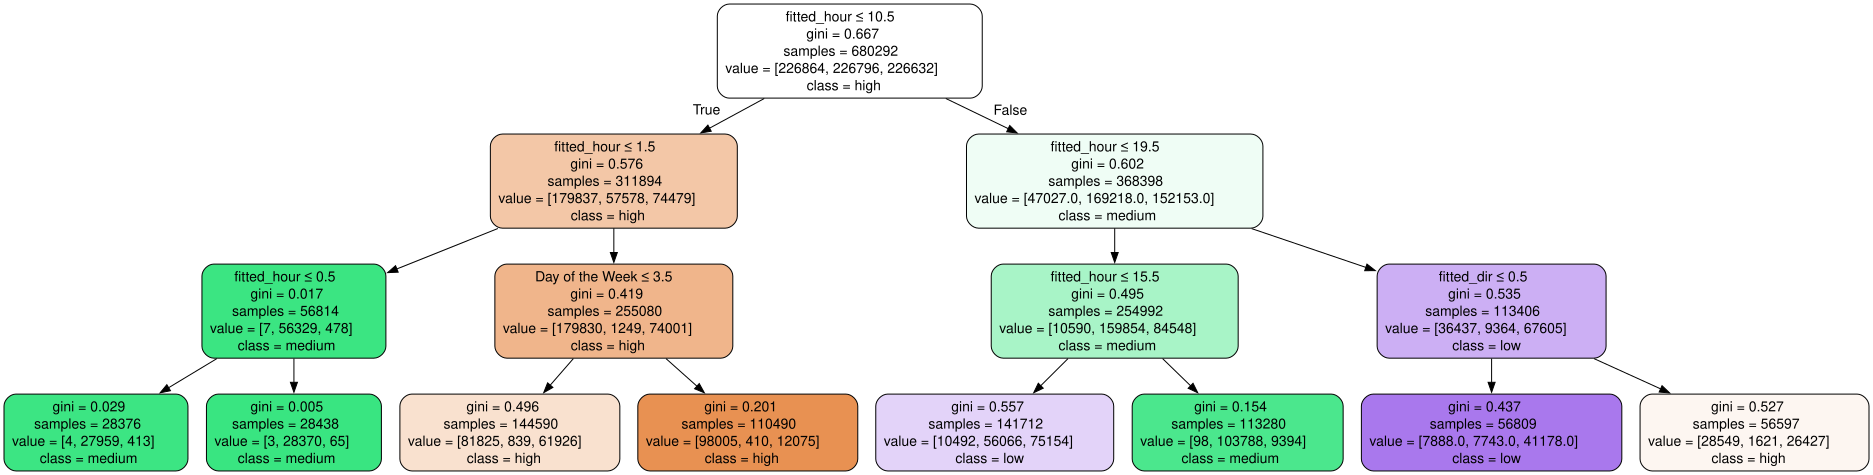

In [22]:
from sklearn.tree import export_graphviz
import graphviz
import pydotplus

dot_data = export_graphviz(clf,
                           feature_names=('Day of the Week','Station ID', 'fitted_dir', 'fitted_hour', 'fitted_month'),
                           class_names=['high','medium','low'],
                           filled=True,
                           rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)

In [23]:
see_hours = melted_df
see_hours = see_hours.drop_duplicates('fitted_hour')
print(see_hours[['Hour','fitted_hour']])

see_month = melted_df
see_month = see_month.drop_duplicates('fitted_month')
print(see_month[['COUNTDATE','fitted_month']])

see_dir = melted_df
see_dir = see_dir.drop_duplicates('fitted_dir')
print(see_dir[['COUNTDIR','fitted_dir']])

          Hour  fitted_hour
0        HOUR0            0
37794    HOUR1            1
75588    HOUR2           12
113382   HOUR3           17
151176   HOUR4           18
188970   HOUR5           19
226764   HOUR6           20
264558   HOUR7           21
302352   HOUR8           22
340146   HOUR9           23
377940  HOUR10            2
415734  HOUR11            3
453528  HOUR12            4
491322  HOUR13            5
529116  HOUR14            6
566910  HOUR15            7
604704  HOUR16            8
642498  HOUR17            9
680292  HOUR18           10
718086  HOUR19           11
755880  HOUR20           13
793674  HOUR21           14
831468  HOUR22           15
869262  HOUR23           16
     COUNTDATE  fitted_month
0   2001-01-01             0
62  2001-02-01             4
118 2001-03-01             5
180 2001-04-01             6
222 2001-05-01             7
284 2001-06-01             8
344 2001-07-01             9
406 2001-08-01            10
462 2001-09-01            11
501 2001-1

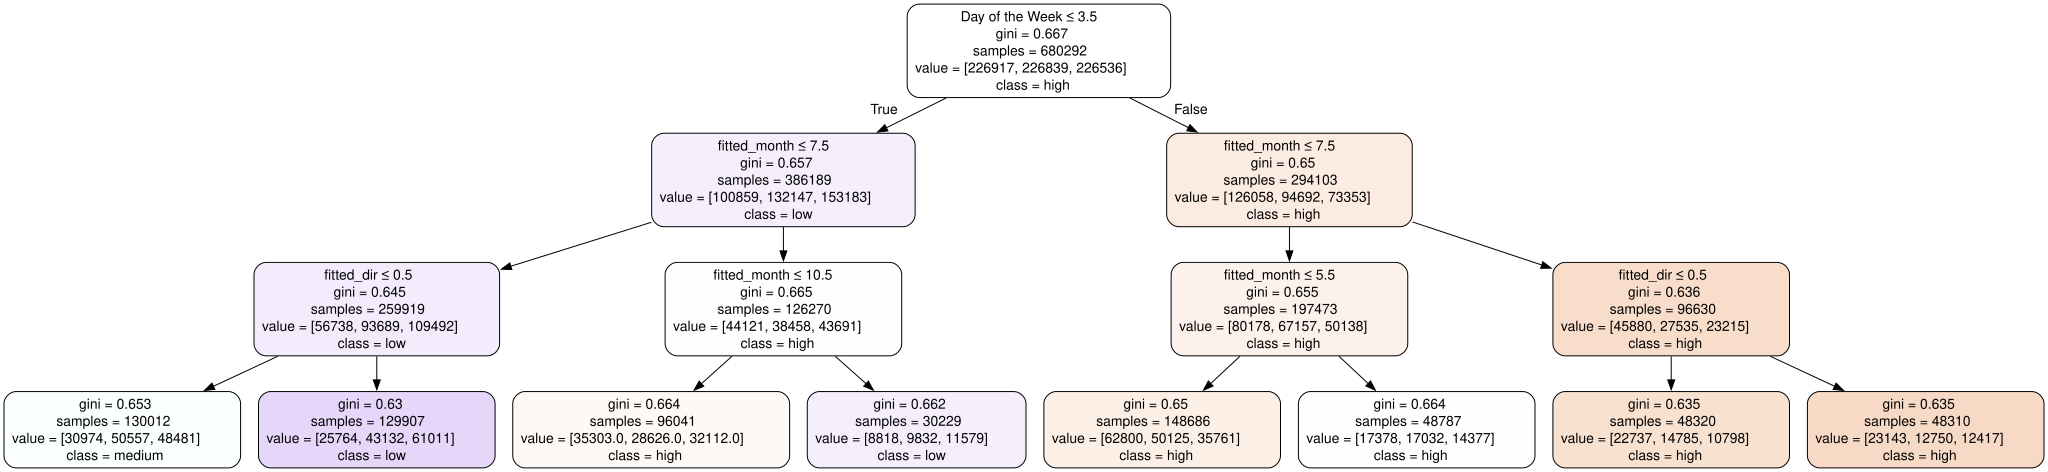

In [24]:
dot_data = export_graphviz(clf_2,
                           feature_names=('Day of the Week','Station ID', 'fitted_dir', 'fitted_month'),
                           class_names=['high','medium','low'],
                           filled=True,
                           rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)